# 전기·전자 산업 ESG 등급 EDA

**데이터** — `KCGS_전기전자_20222025.csv` (공동작업 KCGS_평가등급_20222025.xlsx 변환)
전기·전자 업종 377행 / 고유기업 110개사 / 평가년도 2022~2025
KCGS ESG 통합·E·S·G 등급 + 시장구분 + **산업코드(KSIC)** + 시가총액 + 보고서 2종 발행 여부

**직전 데이터셋 대비 달라진 점**

| 항목 | 이전 | 이번 |
|---|---|---|
| 대상 업종 | 4개 산업(전기·전자/건설/유통/화학) | **전기·전자 단독** |
| 보고서 발행 플래그 | 2025년만 유효, 2022~24 전부 0 | **2022~2025 4개년 모두 유효** |
| 세부 섹터 | 없음 | **산업코드(KSIC) 제공** |

→ 이전에 **검증 불가**였던 두 축이 열렸다.
① 보고서 발행의 **시계열 선후관계** ② **세부 섹터** 기반 가설(H2-1·H2-2)
→ 대신 4개 산업 **횡단 비교는 불가능**하다. H1-1~H1-4는 **전기·전자 한정**으로 검증한다.

**원칙**
1. 이 데이터에 없는 기업·변수는 추가하지 않는다. 외부 분류를 추정해 만들지 않는다.
2. 인과 표현을 쓰지 않는다. 상관·설명력·선후관계 수준으로만 기술한다.
3. 표본 10개 미만 구간의 비율은 단독 근거로 쓰지 않고 n을 함께 표기한다.

**가설**

| No | 가설 | 비고 |
|---|---|---|
| H1-1 | ESG 등급과 기업 규모는 선형성을 보인다 | 전기·전자 한정 |
| H1-2 | 규모 통제 후 등급–지속가능경영보고서 상관이 사라진다 | |
| H1-3 | 등급 상승군의 패턴은 규모와 무관하다 | |
| H1-4 | 등급 하락군은 이미 보고서를 발간했다 | **4개년 시계열로 검증** |
| H2-1 | 반도체·2차전지·전선 섹터에는 양극화가 없다 | **KSIC로 검증** |
| H2-2 | 등급 상승군은 세부 섹터와 무관하다 | **KSIC로 검증** |
| **H+1** | 보고서 신규 발행이 등급 상승에 **선행**한다 | 신설 |
| **H+2** | 상승군과 하락군은 E·S·G 중 특정 영역에서 갈린다 | |
| **H+3** | 등급·E/S/G·규모·보고서로 군집화하면 상위/하위가 자연 분리된다 | |

## 0. 환경 설정

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.unicode.east_asian_width', True)

# ── 한글 폰트 ────────────────────────────────────────────────
# 새 가상환경은 matplotlib 폰트 캐시가 비어 OS 폰트를 못 찾을 수 있다.
# 캐시를 다시 만들고 폰트 파일을 직접 등록한다.
from pathlib import Path
from matplotlib import font_manager as fm
try:
    fm._load_fontmanager(try_read_cache=False)
except Exception:
    pass
for _f in [r'C:/Windows/Fonts/malgun.ttf', r'C:/Windows/Fonts/NanumGothic.ttf',
           r'C:/Windows/Fonts/gulim.ttc', '/System/Library/Fonts/AppleSDGothicNeo.ttc',
           '/usr/share/fonts/truetype/nanum/NanumGothic.ttf']:
    if Path(_f).exists():
        try: fm.fontManager.addfont(_f)
        except Exception: pass

_have = {f.name for f in fm.fontManager.ttflist}
_cands = (['Malgun Gothic', 'AppleSDGothicNeo', 'AppleGothic', 'NanumGothic', 'Gulim']
          + sorted(n for n in _have if 'CJK' in n)
          + sorted(n for n in _have if 'Nanum' in n or 'Gothic' in n))
_FONT = next((f for f in _cands if f in _have), 'DejaVu Sans')

sns.set_style('whitegrid')          # 스타일 먼저 → 폰트를 덮어쓴다
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = [_FONT] + list(mpl.rcParams['font.sans-serif'])
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110
print('적용 폰트 :', _FONT)

GRADE_ORDER = ['A+', 'A', 'B+', 'B', 'C', 'D']
GRADE_MAP   = {'A+': 6, 'A': 5, 'B+': 4, 'B': 3, 'C': 2, 'D': 1}
INV_MAP     = {v: k for k, v in GRADE_MAP.items()}
GRADE_COLOR = {'A+': '#1F3864', 'A': '#2E75B6', 'B+': '#9DC3E6',
               'B': '#F4B183', 'C': '#ED7D31', 'D': '#C00000'}
GRP_COLOR   = {'상승군': '#2E75B6', '정체군': '#BFBFBF', '하락군': '#C00000'}
YEARS = [2022, 2023, 2024, 2025]

적용 폰트 : NanumGothic


## 1. 데이터 로드

In [2]:
CSV_PATH = 'KCGS_전기전자_20222025.csv'   # 경로가 다르면 여기만 수정

raw = pd.read_csv(CSV_PATH, dtype={'기업코드': str, '산업코드': str})
raw['기업코드'] = raw['기업코드'].str.zfill(6)
print('shape :', raw.shape)
print('컬럼  :', list(raw.columns))
raw.head(3)

shape : (377, 22)
컬럼  : ['기업명', '기업코드', '평가년도', 'ESG등급', '환경', '사회', '지배구조', 'ESG 등급조정', '환경 등급조정', '사회 등급조정', '지배구조 등급조정', '시장구분', '업종명', '산업코드', '종가', '대비', '등락률', '시가총액', '지속가능경영보고서_발행', '기업지배구조보고서_발행', '보고서_발행_유형', '비고']


,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정,시장구분,업종명,산업코드,종가,대비,등락률,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형,비고
0,가온전선,000500,2022,B,C,B+,B+,NaN,NaN,NaN,NaN,KOSPI,전기·전자,C28302,NaN,NaN,NaN,NaN,1,0,지속가능경영,NaN
1,가온전선,000500,2023,B+,B+,A,B,NaN,NaN,NaN,NaN,KOSPI,전기·전자,C28302,NaN,NaN,NaN,NaN,1,0,지속가능경영,NaN
2,가온전선,000500,2024,B,A,A,C,NaN,NaN,NaN,NaN,KOSPI,전기·전자,C28302,NaN,NaN,NaN,NaN,1,1,둘 다 발행,NaN


### 1-1. 데이터 품질 점검

In [3]:
df = raw.dropna(subset=['기업명', '평가년도']).copy()
df['평가년도'] = df['평가년도'].astype(int)

print('[연도별 커버리지]')
print(df.groupby('평가년도').agg(
    행수=('기업코드', 'size'), 고유기업=('기업코드', 'nunique'),
    ESG등급=('ESG등급', 'count'), 시가총액=('시가총액', 'count'),
    지속가능경영보고서=('지속가능경영보고서_발행', 'count'),
    기업지배구조보고서=('기업지배구조보고서_발행', 'count')).to_string())

print()
print('[연도별 보고서 발행 = 1]')
print(df.groupby('평가년도')[['지속가능경영보고서_발행', '기업지배구조보고서_발행']]
        .sum().astype(int).to_string())

[연도별 커버리지]
          행수  고유기업  ESG등급  시가총액  지속가능경영보고서  기업지배구조보고서
평가년도                                                                           
2022        92        92       92         0                  92                  92
2023        88        88       88         0                  88                  88
2024        96        96       96         0                  96                  96
2025       101       101      101       101                 101                 101

[연도별 보고서 발행 = 1]
          지속가능경영보고서_발행  기업지배구조보고서_발행
평가년도                                                  
2022                           22                       21
2023                           35                       29
2024                           42                       42
2025                           44                       43


**보고서 발행이 4개년 모두 채워져 있다.** 2022년 22개사 → 2025년 44개사로 증가한다.
직전 데이터셋에서 2022~2024년이 전부 0이라 포기했던 **시계열 선후관계 분석이 가능해졌다.**

다만 **시가총액은 여전히 2025년 행에만 존재한다.**
→ 규모 통제는 2025년 시점 값으로만 가능하며, "올라서 커진 기업"과 "원래 컸던 기업"은 구분되지 않는다.

### 1-2. 산업코드(KSIC) 확인

In [4]:
df['KSIC3'] = df['산업코드'].str[:4]          # 'C' + 3자리 = KSIC 소분류

# KSIC 10차 개정 기준 명칭
KSIC_NAME = {
    'C261': '반도체',              'C262': '전자부품',
    'C263': '컴퓨터·주변장치',      'C264': '통신·방송장비',
    'C265': '영상·음향기기',        'C281': '전동기·전기변환·제어',
    'C282': '일차전지·축전지',      'C283': '절연선·케이블(전선)',
    'C284': '전구·조명',           'C285': '가정용기기',
    'C289': '기타 전기장비',
}
df['섹터'] = df['KSIC3'].map(KSIC_NAME).fillna('기타(코드 확인 필요)')

s25 = df[df['평가년도'] == 2025]
print('[2025년 KSIC 섹터 분포]')
print(s25['섹터'].value_counts().to_string())

odd = s25[~s25['KSIC3'].str.startswith(('C26', 'C28'), na=False)]
if len(odd):
    print()
    print('[C26/C28 밖으로 분류된 기업 — 산업코드 확인 필요]')
    print(odd[['기업명', '산업코드', 'ESG등급']].to_string(index=False))

[2025년 KSIC 섹터 분포]
섹터
전자부품                36
반도체                  19
전동기·전기변환·제어    10
통신·방송장비            9
일차전지·축전지          9
영상·음향기기            6
절연선·케이블(전선)      4
가정용기기               2
기타 전기장비            2
컴퓨터·주변장치          2
전구·조명                1
기타(코드 확인 필요)     1

[C26/C28 밖으로 분류된 기업 — 산업코드 확인 필요]
 기업명 산업코드 ESG등급
삼성SDI    C8202       A


> **확인 필요** — 삼성SDI의 산업코드가 `C8202`로 들어와 있다.
> KSIC에서 C82는 전기·전자 제조업이 아니므로 **입력 오류로 보인다**(사업 내용상 `C282 일차전지·축전지`가 타당).
> 본 분석에서는 값을 임의로 고치지 않고 `기타(코드 확인 필요)`로 분리해 표기하며,
> 섹터별 통계에서 1개사 집단으로 남는다. 팀에서 원본을 확인해 정정할 것.

## 2. 파생변수 생성

In [5]:
for c in ['ESG등급', '환경', '사회', '지배구조']:
    df[c + '_점수'] = df[c].map(GRADE_MAP)

# 연도 × 기업 와이드 테이블
W_GRADE = df.pivot_table(index='기업코드', columns='평가년도', values='ESG등급_점수')
W_AREA  = {a: df.pivot_table(index='기업코드', columns='평가년도', values=a + '_점수')
           for a in ['환경', '사회', '지배구조']}
W_SR    = df.pivot_table(index='기업코드', columns='평가년도', values='지속가능경영보고서_발행')
W_GR    = df.pivot_table(index='기업코드', columns='평가년도', values='기업지배구조보고서_발행')

# 2025년 횡단면을 기준 패널로
p = (df[df['평가년도'] == 2025]
     .set_index('기업코드')[['기업명', '시장구분', '섹터', 'KSIC3', '산업코드', '시가총액',
                            'ESG등급', 'ESG등급_점수', '환경', '사회', '지배구조',
                            '환경_점수', '사회_점수', '지배구조_점수']].copy())
p['시가총액_억'] = p['시가총액'] / 1e8
p['log시총']    = np.log10(p['시가총액'])

for y in YEARS:
    p[f'등급_{y}'] = W_GRADE[y].reindex(p.index)
    p[f'지속_{y}'] = W_SR[y].reindex(p.index)
    p[f'지배_{y}'] = W_GR[y].reindex(p.index)

p['전이'] = p['등급_2025'] - p['등급_2022']
p['변동군'] = p['전이'].map(lambda v: '추적불가' if pd.isna(v)
                          else ('상승군' if v > 0 else ('하락군' if v < 0 else '정체군')))
p['시총분위'] = pd.qcut(p['시가총액'], 4, labels=['Q1(소)', 'Q2', 'Q3', 'Q4(대)'])

# E/S/G 영역별 2022→2025 변화
for a in ['환경', '사회', '지배구조']:
    p[a + '_변화'] = (W_AREA[a][2025] - W_AREA[a][2022]).reindex(p.index)

print(f'패널 : {p.shape}   (2025년 평가 대상 {len(p)}개사)')
print()
print('[변동군]', p['변동군'].value_counts().to_dict())

패널 : (101, 34)   (2025년 평가 대상 101개사)

[변동군] {'정체군': 43, '상승군': 33, '추적불가': 17, '하락군': 8}


---
# Part 1. 전기·전자 전체 EDA

### 1-0. 등급 분포와 4개년 추이

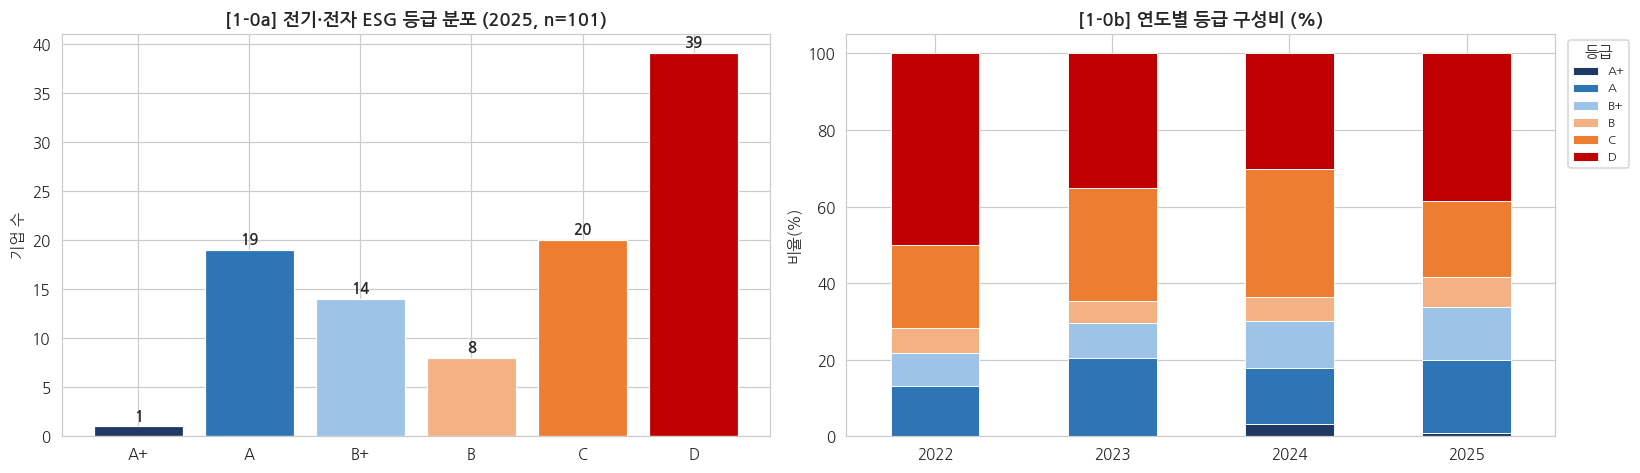

[등급 분포] {'A+': 1, 'A': 19, 'B+': 14, 'B': 8, 'C': 20, 'D': 39}
상위군(A+~B+) 34개사 33.7%  |  B 8개사 7.9%  |  하위군(C·D) 59개사 58.4%
표준편차 1.60  양극단비중 0.92


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))

dist = p['ESG등급'].value_counts().reindex(GRADE_ORDER).fillna(0).astype(int)
axes[0].bar(dist.index, dist.values, color=[GRADE_COLOR[g] for g in dist.index],
            edgecolor='white', linewidth=0.8)
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 0.6, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title(f'[1-0a] 전기·전자 ESG 등급 분포 (2025, n={len(p)})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('기업 수')

yr = (df.groupby(['평가년도', 'ESG등급']).size().unstack()
        .reindex(columns=GRADE_ORDER).fillna(0))
(yr.div(yr.sum(axis=1), axis=0) * 100).plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[GRADE_COLOR[g] for g in GRADE_ORDER], edgecolor='white', linewidth=0.6)
axes[1].set_title('[1-0b] 연도별 등급 구성비 (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('비율(%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='등급', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

print('[등급 분포]', dist.to_dict())
hi, mid, lo = int((p['ESG등급_점수'] >= 4).sum()), int((p['ESG등급_점수'] == 3).sum()), int((p['ESG등급_점수'] <= 2).sum())
print(f'상위군(A+~B+) {hi}개사 {hi/len(p)*100:.1f}%  |  B {mid}개사 {mid/len(p)*100:.1f}%  |  하위군(C·D) {lo}개사 {lo/len(p)*100:.1f}%')
print(f'표준편차 {p["ESG등급_점수"].std():.2f}  양극단비중 {(hi+lo)/len(p):.2f}')

### H1-1. ESG 등급과 기업 규모는 선형성을 보이는가

[H1-1] n=101  Pearson r=0.703 (p=2.41e-16)  Spearman rho=0.707  R²=0.495

[시가총액 4분위별]
           n  평균등급  시총중앙_억
시총분위                           
Q1(소)    26      1.15          614
Q2        25      2.32         3917
Q3        25      2.52         9076
Q4(대)    25      4.36        87504
단조 증가 : True


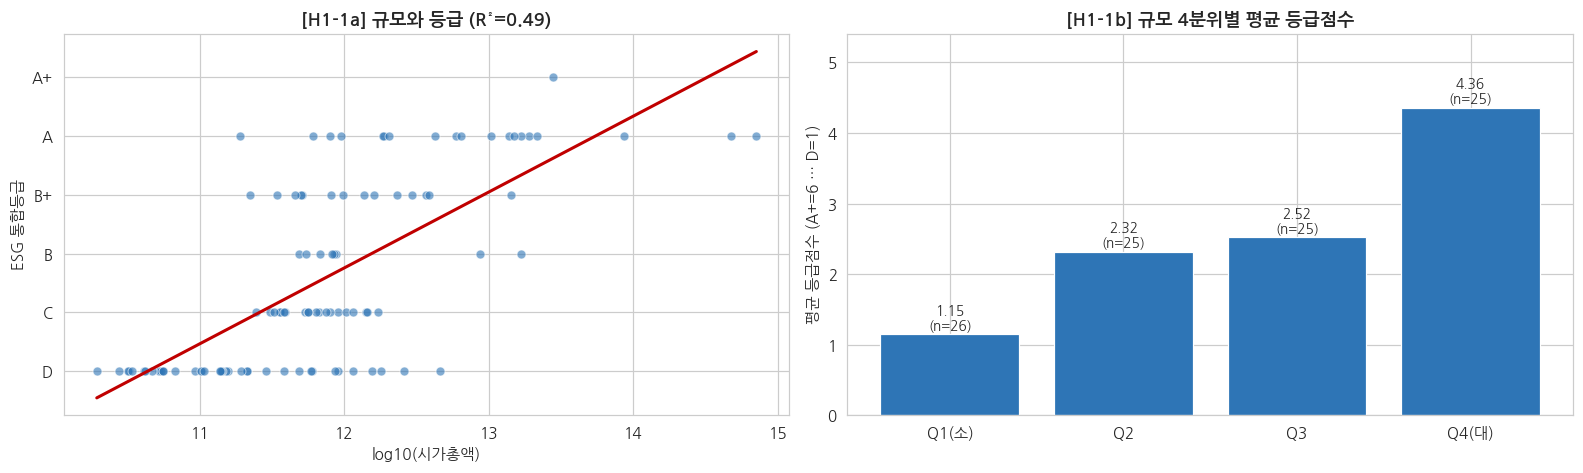

In [7]:
x = p.dropna(subset=['log시총', 'ESG등급_점수'])
pr, pp = stats.pearsonr(x['log시총'], x['ESG등급_점수'])
sr, sp = stats.spearmanr(x['log시총'], x['ESG등급_점수'])
sl, ic, rv, pv, se = stats.linregress(x['log시총'], x['ESG등급_점수'])
print(f'[H1-1] n={len(x)}  Pearson r={pr:.3f} (p={pp:.2e})  '
      f'Spearman rho={sr:.3f}  R²={rv**2:.3f}')

q = p.groupby('시총분위', observed=True).agg(
    n=('ESG등급_점수', 'size'), 평균등급=('ESG등급_점수', 'mean'),
    시총중앙_억=('시가총액_억', 'median')).round(2)
q['시총중앙_억'] = q['시총중앙_억'].round(0).astype(int)
print()
print('[시가총액 4분위별]'); print(q.to_string())
mono = bool(np.all(np.diff(q['평균등급'].values) > 0))
print(f'단조 증가 : {mono}')

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
axes[0].scatter(x['log시총'], x['ESG등급_점수'], s=34, alpha=0.6,
                color='#2E75B6', edgecolor='white', linewidth=0.6)
xs = np.linspace(x['log시총'].min(), x['log시총'].max(), 50)
axes[0].plot(xs, sl * xs + ic, color='#C00000', lw=2)
axes[0].set_yticks(list(INV_MAP)); axes[0].set_yticklabels([INV_MAP[k] for k in INV_MAP])
axes[0].set_title(f'[H1-1a] 규모와 등급 (R²={rv**2:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log10(시가총액)'); axes[0].set_ylabel('ESG 통합등급')

axes[1].bar(q.index.astype(str), q['평균등급'], color='#2E75B6',
            edgecolor='white', linewidth=0.8)
for i, (v, n) in enumerate(zip(q['평균등급'], q['n'])):
    axes[1].text(i, v + 0.06, f'{v:.2f}\n(n={n})', ha='center', fontsize=9)
axes[1].set_title('[H1-1b] 규모 4분위별 평균 등급점수', fontsize=12, fontweight='bold')
axes[1].set_ylabel('평균 등급점수 (A+=6 … D=1)'); axes[1].set_ylim(0, 5.4)
plt.tight_layout(); plt.show()

### H1-2. 규모를 통제하면 등급–보고서 상관이 사라지는가

In [8]:
def partial_corr(a, b, z):
    """z를 통제한 a-b 편상관 (각각 z에 회귀시킨 잔차 간 상관)"""
    a, b, z = map(np.asarray, (a, b, z))
    ra = a - np.polyval(np.polyfit(z, a, 1), z)
    rb = b - np.polyval(np.polyfit(z, b, 1), z)
    return stats.pearsonr(ra, rb)

rows = []
for col, nm in [('지속_2025', '지속가능경영보고서'), ('지배_2025', '기업지배구조보고서')]:
    y = p.dropna(subset=[col, 'ESG등급_점수', 'log시총'])
    r0, p0 = stats.pearsonr(y[col], y['ESG등급_점수'])
    r1, p1 = partial_corr(y[col], y['ESG등급_점수'], y['log시총'])
    rs, _ = stats.pearsonr(y[col], y['log시총'])
    rows.append([nm, len(y), int(y[col].sum()), round(r0, 3), round(r1, 3),
                 f'{p1:.2e}', f'{(1-abs(r1)/abs(r0))*100:.0f}%', round(rs, 3)])
h12 = pd.DataFrame(rows, columns=['보고서', 'n', '발행기업수', '단순 r',
                                  '규모통제 편상관', 'p(편상관)', '감소폭', '규모와 상관'])
print('[H1-2] 2025년 기준')
print(h12.to_string(index=False))

[H1-2] 2025년 기준
            보고서   n  발행기업수  단순 r  규모통제 편상관 p(편상관) 감소폭  규모와 상관
지속가능경영보고서 101          44   0.623            0.351  3.16e-04    44%        0.602
기업지배구조보고서 101          43   0.670            0.459  1.40e-06    31%        0.571


[H1-2] 규모 분위 × 보고서 발행 여부별 평균 등급
                     n  평균등급
시총분위 지속_2025              
Q1(소)   0.0        24      1.17
         1.0         2      1.00
Q2       0.0        19      2.05
         1.0         6      3.17
Q3       0.0        11      1.82
         1.0        14      3.07
Q4(대)   0.0         3      3.33
         1.0        22      4.50


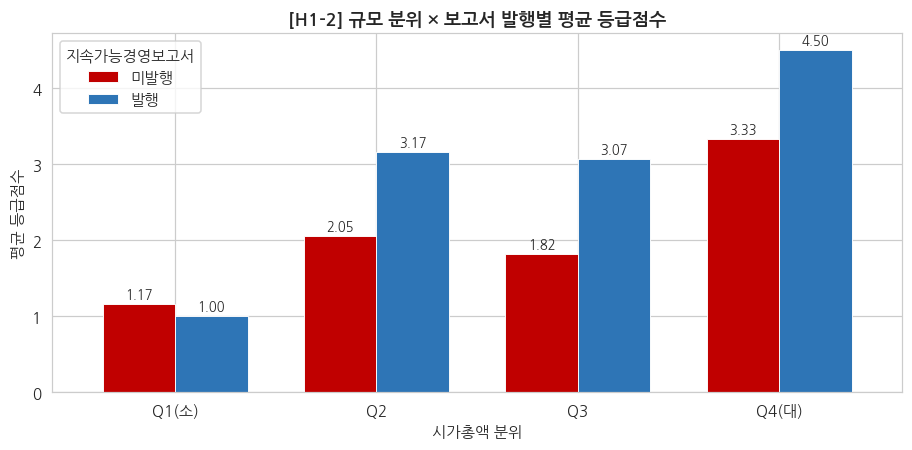

In [9]:
tab = (p.groupby(['시총분위', '지속_2025'], observed=True)
         .agg(n=('ESG등급_점수', 'size'), 평균등급=('ESG등급_점수', 'mean')).round(2))
print('[H1-2] 규모 분위 × 보고서 발행 여부별 평균 등급')
print(tab.to_string())

pt = (p.groupby(['시총분위', '지속_2025'], observed=True)['ESG등급_점수'].mean().unstack())
pt.columns = ['미발행', '발행']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
pt.plot(kind='bar', ax=ax, color=['#C00000', '#2E75B6'], width=0.72,
        edgecolor='white', linewidth=0.6)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8.5, padding=2)
ax.set_title('[H1-2] 규모 분위 × 보고서 발행별 평균 등급점수', fontsize=12, fontweight='bold')
ax.set_xlabel('시가총액 분위'); ax.set_ylabel('평균 등급점수')
ax.tick_params(axis='x', rotation=0); ax.legend(title='지속가능경영보고서')
plt.tight_layout(); plt.show()

### H1-3. 등급 상승군의 패턴은 규모와 무관한가

[H1-3] 규모 vs 전이  Spearman rho=+0.251  p=0.0211  (n=84)

[시가총액 분위별 등급 전이]
           n  평균전이  상승  정체  하락  상승률(%)
시총분위                                           
Q1(소)    25     -0.04     1    22     2        4.0
Q2        18      0.56    10     5     3       55.6
Q3        19      1.00    13     5     1       68.4
Q4(대)    22      0.45     9    11     2       40.9


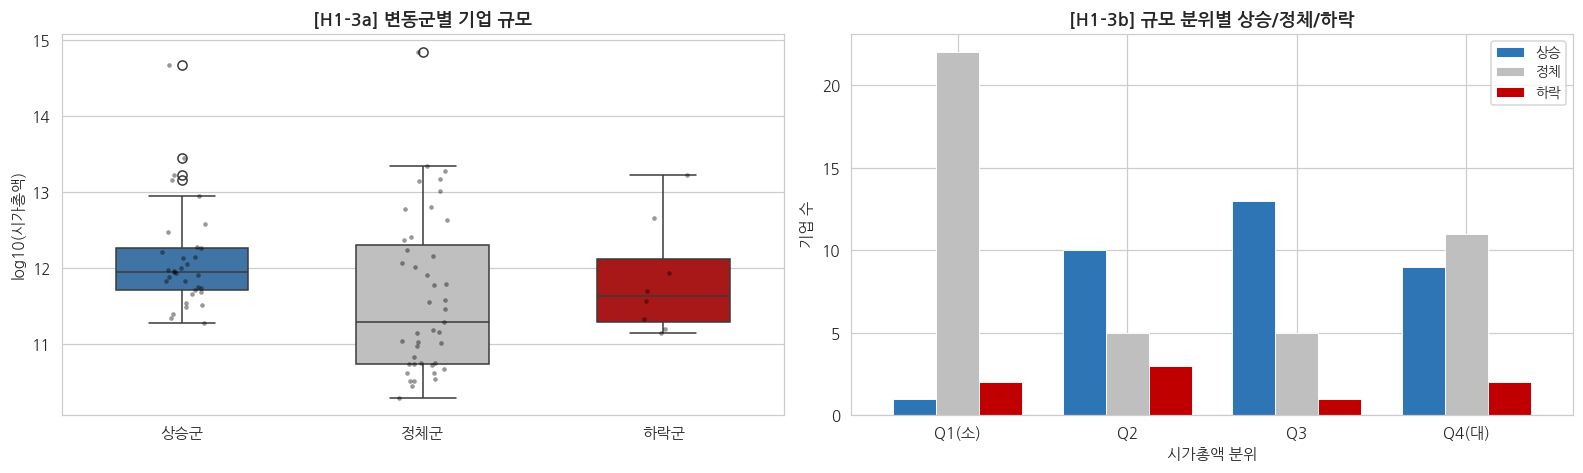

In [10]:
t = p[p['변동군'] != '추적불가'].dropna(subset=['log시총', '전이'])
r, pv = stats.spearmanr(t['log시총'], t['전이'])
print(f'[H1-3] 규모 vs 전이  Spearman rho={r:+.3f}  p={pv:.4f}  (n={len(t)})')
print()
qq = (t.groupby('시총분위', observed=True)['전이']
        .agg(n='size', 평균전이='mean',
             상승=lambda s: int((s > 0).sum()),
             정체=lambda s: int((s == 0).sum()),
             하락=lambda s: int((s < 0).sum())).round(2))
qq['상승률(%)'] = (qq['상승'] / qq['n'] * 100).round(1)
print('[시가총액 분위별 등급 전이]'); print(qq.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
sns.boxplot(data=t, x='변동군', y='log시총', order=['상승군', '정체군', '하락군'],
            palette=[GRP_COLOR[g] for g in ['상승군', '정체군', '하락군']], ax=axes[0], width=0.55)
sns.stripplot(data=t, x='변동군', y='log시총', order=['상승군', '정체군', '하락군'],
              color='black', size=3, alpha=0.4, ax=axes[0])
axes[0].set_title('[H1-3a] 변동군별 기업 규모', fontsize=12, fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('log10(시가총액)')

qq[['상승', '정체', '하락']].plot(kind='bar', ax=axes[1], width=0.76,
    color=[GRP_COLOR[g] for g in ['상승군', '정체군', '하락군']],
    edgecolor='white', linewidth=0.6)
axes[1].set_title('[H1-3b] 규모 분위별 상승/정체/하락', fontsize=12, fontweight='bold')
axes[1].set_xlabel('시가총액 분위'); axes[1].set_ylabel('기업 수')
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### H1-4. 등급 하락군은 이미 보고서를 발간했는가 ★4개년 시계열

직전 데이터셋에서는 2025년 단면으로만 볼 수 있었으나, 이번에는 **2022~2025년 4개년 궤적**으로 검증한다.

In [11]:
t = p[p['변동군'] != '추적불가']
sr_rate = (t.groupby('변동군')[[f'지속_{y}' for y in YEARS]].mean() * 100).round(1)
gr_rate = (t.groupby('변동군')[[f'지배_{y}' for y in YEARS]].mean() * 100).round(1)
sr_rate.columns = gr_rate.columns = [str(y) for y in YEARS]
order = ['상승군', '정체군', '하락군']

print('[H1-4] 변동군별 지속가능경영보고서 발행률(%)')
print(sr_rate.reindex(order).to_string())
print()
print('[변동군별 기업지배구조보고서 발행률(%)]')
print(gr_rate.reindex(order).to_string())
print()
print('n :', t['변동군'].value_counts().reindex(order).to_dict())

[H1-4] 변동군별 지속가능경영보고서 발행률(%)
        2022  2023  2024  2025
변동군                        
상승군  24.2  45.5  57.6  60.6
정체군  27.9  39.0  37.2  39.5
하락군  12.5  12.5  12.5  12.5

[변동군별 기업지배구조보고서 발행률(%)]
        2022  2023  2024  2025
변동군                        
상승군  27.3  36.4  60.6  60.6
정체군  23.3  31.7  34.9  34.9
하락군  25.0  25.0  37.5  37.5

n : {'상승군': 33, '정체군': 43, '하락군': 8}


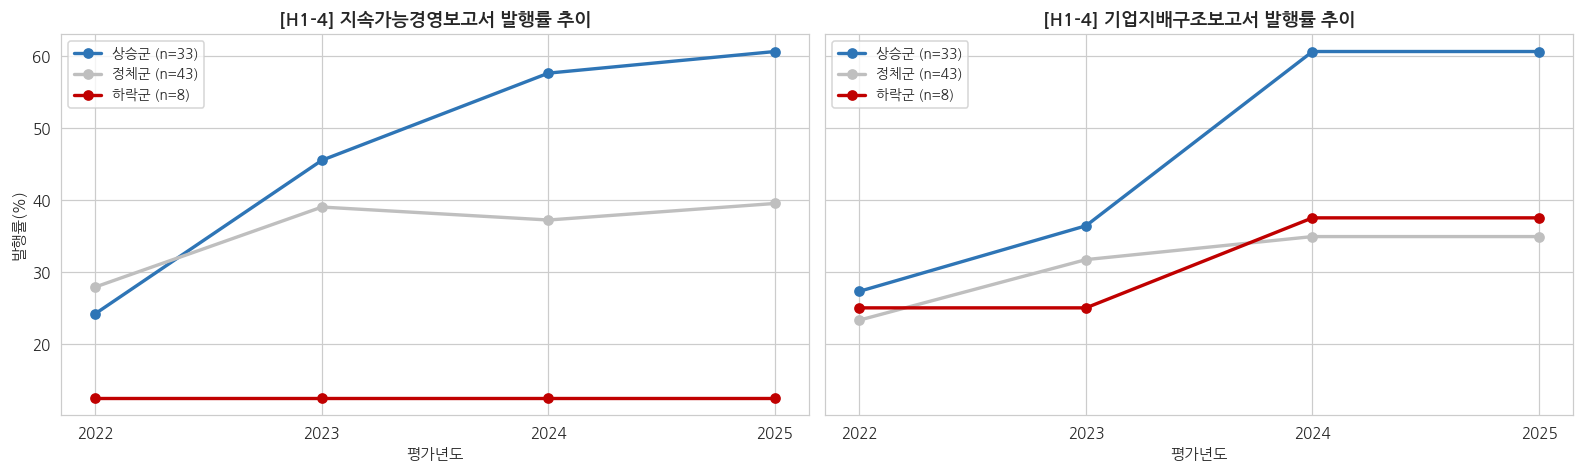

[하락군 개별 — 지속가능경영보고서 4개년]
      기업명 ESG등급  전이                 섹터  지속_2022  지속_2023  지속_2024  지속_2025  시총_억
    대동전자       D  -1.0        통신·방송장비        0.0        0.0        0.0        0.0     1578
    리노공업       D  -1.0             전자부품        0.0        0.0        0.0        0.0    45956
삼영전자공업       D  -1.0             전자부품        0.0        0.0        0.0        0.0     2108
  서울반도체       C  -1.0               반도체        0.0        0.0        0.0        0.0     3621
    신도리코       D  -1.0      컴퓨터·주변장치        0.0        0.0        0.0        0.0     4899
  효성중공업       B  -2.0 전동기·전기변환·제어        1.0        1.0        1.0        1.0   166070
         KEC       D  -1.0               반도체        0.0        0.0        0.0        0.0     1397
       RFHIC       D  -1.0        통신·방송장비        0.0        0.0        0.0        0.0     8653


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4), sharey=True)
for ax, (tbl, ttl) in zip(axes, [(sr_rate, '지속가능경영보고서'), (gr_rate, '기업지배구조보고서')]):
    for g in order:
        ax.plot([int(c) for c in tbl.columns], tbl.loc[g], marker='o', lw=2.2,
                color=GRP_COLOR[g], label=f'{g} (n={int((t["변동군"]==g).sum())})')
    ax.set_title(f'[H1-4] {ttl} 발행률 추이', fontsize=12, fontweight='bold')
    ax.set_xlabel('평가년도'); ax.set_xticks(YEARS)
    ax.legend(fontsize=9)
axes[0].set_ylabel('발행률(%)')
plt.tight_layout(); plt.show()

print('[하락군 개별 — 지속가능경영보고서 4개년]')
dn = t[t['변동군'] == '하락군'][['기업명', 'ESG등급', '전이', '섹터'] +
                              [f'지속_{y}' for y in YEARS]].copy()
dn['시총_억'] = t.loc[dn.index, '시가총액_억'].round(0).astype(int)
print(dn.to_string(index=False))

### H+1. (신설) 보고서 신규 발행이 등급 상승에 **선행**하는가 ★

지금까지 "발행이 먼저인가 등급이 먼저인가"는 데이터가 없어 판단할 수 없었다.
4개년 플래그가 확보되었으므로 **2022년 미발행 기업**을 두 갈래로 나눠 이후 등급 변화를 비교한다.

- **신규 발행군** : 2022년 미발행 → 2023 또는 2024년에 발행 시작
- **계속 미발행군** : 4개년 내내 미발행

출발점(2022년 미발행)이 같으므로, 이후 등급 변화의 차이를 발행 여부와 연결해 볼 수 있다.

In [13]:
t = p[p['변동군'] != '추적불가'].copy()
base_no = t[t['지속_2022'] == 0]
newpub = base_no[(base_no['지속_2023'] == 1) | (base_no['지속_2024'] == 1)]
nopub  = base_no[(base_no[[f'지속_{y}' for y in YEARS]].sum(axis=1) == 0)]

rows = []
for nm, g in [('신규 발행군', newpub), ('계속 미발행군', nopub)]:
    rows.append([nm, len(g), round(g['전이'].mean(), 2),
                 int((g['전이'] > 0).sum()), round((g['전이'] > 0).mean() * 100, 1),
                 round(g['시가총액_억'].median())])
h_pre = pd.DataFrame(rows, columns=['집단', 'n', '평균 전이', '상승 기업수', '상승률(%)', '시총중앙_억'])
print('[H+1] 2022년 미발행 기업의 이후 등급 변화')
print(h_pre.to_string(index=False))

u, pv = stats.mannwhitneyu(newpub['전이'], nopub['전이'])
print(f'\nMann-Whitney U : p={pv:.4f}')

# 규모 차이가 아닌지 확인
u2, pv2 = stats.mannwhitneyu(newpub['시가총액_억'], nopub['시가총액_억'])
print(f'두 집단의 시가총액 차이 : p={pv2:.4f}  '
      f'(유의하면 규모 효과일 수 있으므로 해석 주의)')

[H+1] 2022년 미발행 기업의 이후 등급 변화
         집단  n  평균 전이  상승 기업수  상승률(%)  시총중앙_억
  신규 발행군 16       1.31           12       75.0         9650
계속 미발행군 44       0.16           11       25.0         1911

Mann-Whitney U : p=0.0001
두 집단의 시가총액 차이 : p=0.0001  (유의하면 규모 효과일 수 있으므로 해석 주의)


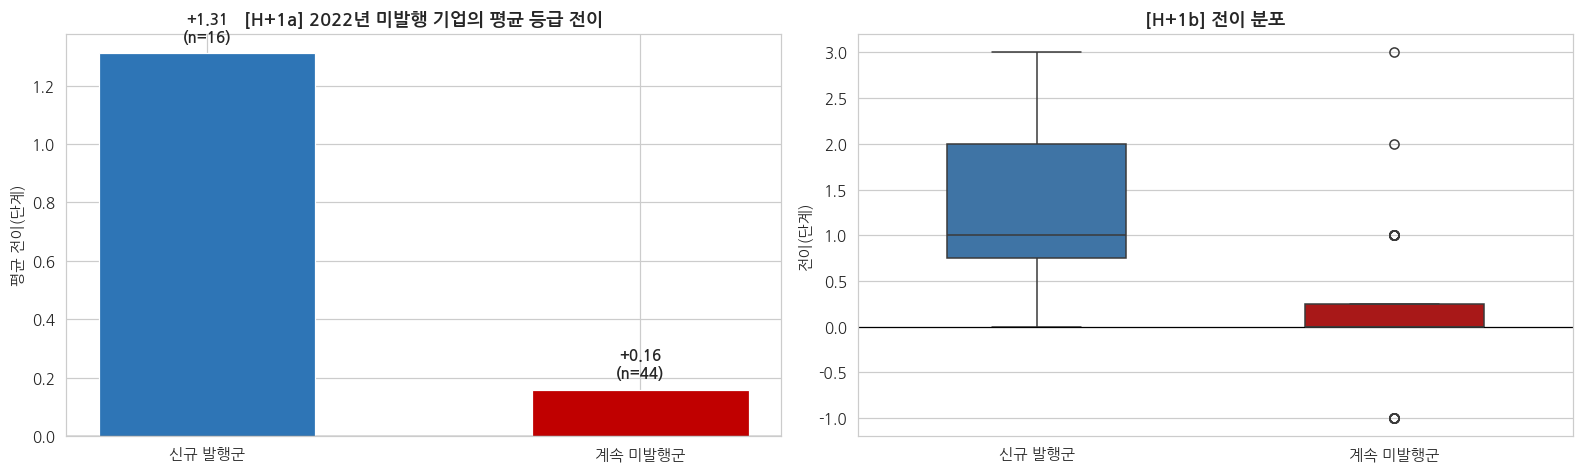

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
axes[0].bar(h_pre['집단'], h_pre['평균 전이'], color=['#2E75B6', '#C00000'],
            width=0.5, edgecolor='white', linewidth=0.8)
for i, (v, n) in enumerate(zip(h_pre['평균 전이'], h_pre['n'])):
    axes[0].text(i, v + 0.04, f'{v:+.2f}\n(n={n})', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('[H+1a] 2022년 미발행 기업의 평균 등급 전이', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 전이(단계)')

sns.boxplot(data=pd.concat([newpub.assign(집단='신규 발행군'), nopub.assign(집단='계속 미발행군')]),
            x='집단', y='전이', palette=['#2E75B6', '#C00000'], ax=axes[1], width=0.5)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('[H+1b] 전이 분포', fontsize=12, fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('전이(단계)')
plt.tight_layout(); plt.show()

### H+2. 상승군과 하락군은 E·S·G 중 어디에서 갈리는가

[H+2] 변동군별 E/S/G 영역 변화 (2022→2025)
    영역  상승군 평균변화  상승군 상승수  정체군 평균변화  정체군 상승수  하락군 평균변화  하락군 상승수
    환경             1.76             32             0.65             27             0.25              2
    사회             1.73             28             0.12              8             0.12              2
지배구조             0.45             16            -0.26              3            -2.12              0

[2025년 영역별 평균 등급점수]
환경(E)        2.93
사회(S)        3.30
지배구조(G)    2.25


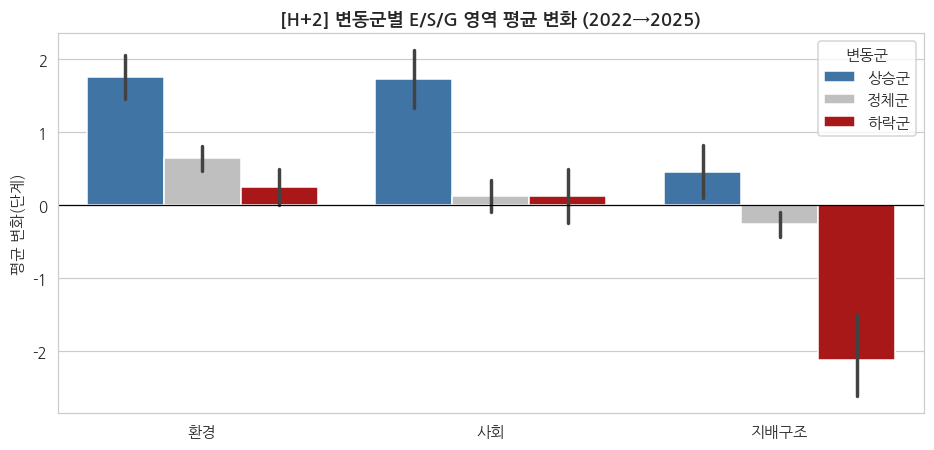

In [15]:
t = p[p['변동군'] != '추적불가']
rows = []
for a in ['환경', '사회', '지배구조']:
    r = {'영역': a}
    for g in ['상승군', '정체군', '하락군']:
        s = t[t['변동군'] == g][a + '_변화'].dropna()
        r[f'{g} 평균변화'] = round(s.mean(), 2)
        r[f'{g} 상승수'] = int((s > 0).sum())
    rows.append(r)
h2p = pd.DataFrame(rows)
print('[H+2] 변동군별 E/S/G 영역 변화 (2022→2025)')
print(h2p.to_string(index=False))

print()
print('[2025년 영역별 평균 등급점수]')
print(p[['환경_점수', '사회_점수', '지배구조_점수']].mean().round(2)
      .rename({'환경_점수': '환경(E)', '사회_점수': '사회(S)', '지배구조_점수': '지배구조(G)'}).to_string())

plot_df = (t.melt(id_vars='변동군', value_vars=['환경_변화', '사회_변화', '지배구조_변화'],
                  var_name='영역', value_name='변화').dropna(subset=['변화']))
plot_df['영역'] = plot_df['영역'].str.replace('_변화', '', regex=False)
fig, ax = plt.subplots(figsize=(8.6, 4.2))
sns.barplot(data=plot_df, x='영역', y='변화', hue='변동군',
            hue_order=['상승군', '정체군', '하락군'],
            palette=[GRP_COLOR[g] for g in ['상승군', '정체군', '하락군']],
            errorbar=('ci', 95), ax=ax)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('[H+2] 변동군별 E/S/G 영역 평균 변화 (2022→2025)', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('평균 변화(단계)')
plt.tight_layout(); plt.show()

### 1-6. 등급 전이행렬 (2022 → 2025)

[전이행렬] 행=2022, 열=2025  (n=84)
등급_2025  A+   A  B+  B  C   D
등급_2022                      
A           0  11   0  1  0   0
B+          1   5   1  0  0   0
B           0   0   5  0  1   0
C           0   1   4  3  4   6
D           0   0   2  3  9  27


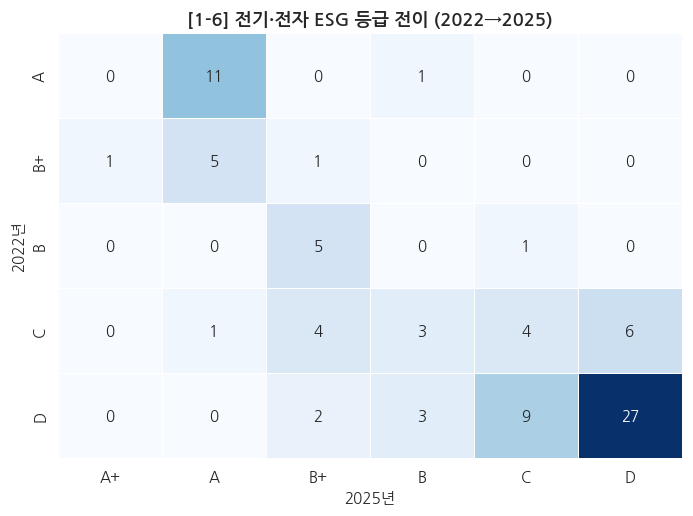

2022년 D등급 41개사 중 D 탈출 : 14개사 (34.1%)


In [16]:
tm = pd.crosstab(p['등급_2022'].map(INV_MAP), p['등급_2025'].map(INV_MAP))
tm = tm.reindex(index=[g for g in GRADE_ORDER if g in tm.index],
                columns=[g for g in GRADE_ORDER if g in tm.columns]).fillna(0).astype(int)
n_tr = int(p['전이'].notna().sum())
print(f'[전이행렬] 행=2022, 열=2025  (n={n_tr})')
print(tm.to_string())

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.heatmap(tm, annot=True, fmt='d', cmap='Blues', cbar=False,
            linewidths=0.6, linecolor='white', ax=ax)
ax.set_title('[1-6] 전기·전자 ESG 등급 전이 (2022→2025)', fontsize=12, fontweight='bold')
ax.set_xlabel('2025년'); ax.set_ylabel('2022년')
plt.tight_layout(); plt.show()

d22 = tm.loc['D'] if 'D' in tm.index else None
if d22 is not None:
    esc = int(d22.drop('D').sum()) if 'D' in d22.index else int(d22.sum())
    print(f"2022년 D등급 {int(d22.sum())}개사 중 D 탈출 : {esc}개사 ({esc/d22.sum()*100:.1f}%)")

---
# Part 2. 세부 섹터 EDA — KSIC 기준

`산업코드`(KSIC 소분류)를 그대로 사용한다. 외부 분류를 추정해 만들지 않았으므로
**섹터 구분은 데이터셋에 있는 값 그대로**다.
가설이 지목한 세 섹터는 KSIC에 다음과 같이 대응한다.

| 가설의 섹터 | KSIC 소분류 |
|---|---|
| 반도체 | **C261** 반도체 제조업 |
| 2차전지 | **C282** 일차전지 및 축전지 제조업 |
| 전선 | **C283** 절연선 및 케이블 제조업 |

### H2-1. 반도체·2차전지·전선 섹터에 양극화가 없는가

**양극화 판정 지표 3가지**를 함께 본다. 표준편차만으로는 이봉(bimodal) 여부를 알 수 없다.
1. **표준편차** — 산포의 크기
2. **양극단비중** = (상위군 A+·A·B+ + 하위군 C·D) / 전체 — 가운데가 빌수록 1에 가깝다
3. **B비중** — 이봉 구조의 '다리' 두께

In [17]:
def polarization(g):
    n = len(g); s = g['ESG등급_점수']
    hi = int((s >= 4).sum()); mid = int((s == 3).sum()); lo = int((s <= 2).sum())
    return pd.Series({'기업수': n, '평균등급': round(s.mean(), 2),
                      '표준편차': round(s.std(), 2) if n > 1 else np.nan,
                      '상위군': hi, 'B': mid, '하위군': lo,
                      '양극단비중': round((hi + lo) / n, 2), 'B비중': round(mid / n, 2)})

pol = p.groupby('섹터').apply(polarization, include_groups=False).sort_values('기업수', ascending=False)
print('[H2-1] KSIC 섹터별 양극화 지표 (2025)')
print(pol.to_string())

hi_a = int((p['ESG등급_점수'] >= 4).sum()); lo_a = int((p['ESG등급_점수'] <= 2).sum())
print(f"\n[전기·전자 전체] std {p['ESG등급_점수'].std():.2f}  "
      f"양극단비중 {(hi_a+lo_a)/len(p):.2f}  B비중 {(p['ESG등급_점수']==3).mean():.2f}")

TARGET = ['반도체', '일차전지·축전지', '절연선·케이블(전선)']
print('\n[가설 지목 3개 섹터]')
print(pol.reindex([t for t in TARGET if t in pol.index]).to_string())

[H2-1] KSIC 섹터별 양극화 지표 (2025)
                      기업수  평균등급  표준편차  상위군    B  하위군  양극단비중  B비중
섹터                                                                                    
전자부품                36.0      2.78      1.49    13.0  4.0    19.0        0.89   0.11
반도체                  19.0      2.21      1.47     4.0  1.0    14.0        0.95   0.05
전동기·전기변환·제어    10.0      2.80      1.93     3.0  2.0     5.0        0.80   0.20
통신·방송장비            9.0      2.33      1.80     3.0  0.0     6.0        1.00   0.00
일차전지·축전지          9.0      3.67      1.41     6.0  1.0     2.0        0.89   0.11
영상·음향기기            6.0      1.50      1.22     1.0  0.0     5.0        1.00   0.00
절연선·케이블(전선)      4.0      2.75      2.06     2.0  0.0     2.0        1.00   0.00
가정용기기               2.0      2.50      2.12     1.0  0.0     1.0        1.00   0.00
컴퓨터·주변장치          2.0      1.00      0.00     0.0  0.0     2.0        1.00   0.00
기타 전기장비            2.0      1.50      0.71     0.0  0.0     2.0        1

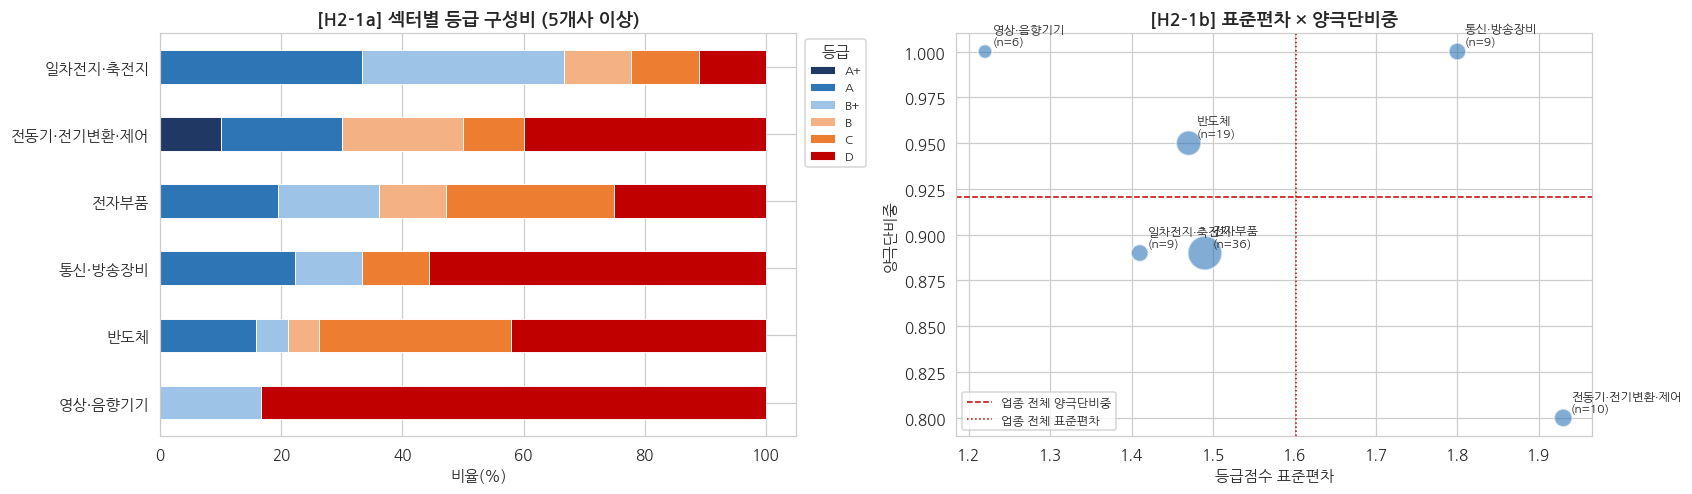

Kruskal-Wallis (섹터 간 등급 수준 차이, 6개 섹터): H=10.047  p=0.0739


In [18]:
big = pol[pol['기업수'] >= 5].index.tolist()
sub = p[p['섹터'].isin(big)]
ct = (pd.crosstab(sub['섹터'], sub['ESG등급'])
        .reindex(columns=GRADE_ORDER).fillna(0).astype(int))
ct = ct.loc[pol.loc[big].sort_values('평균등급').index]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.6))
ct.div(ct.sum(axis=1), axis=0).mul(100).plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[GRADE_COLOR[c] for c in ct.columns], edgecolor='white', linewidth=0.6)
axes[0].set_title('[H2-1a] 섹터별 등급 구성비 (5개사 이상)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('비율(%)'); axes[0].set_ylabel('')
axes[0].legend(title='등급', bbox_to_anchor=(1.005, 1), loc='upper left', fontsize=8)

pb = pol[pol['기업수'] >= 5]
axes[1].scatter(pb['표준편차'], pb['양극단비중'], s=pb['기업수'] * 14, alpha=0.6,
                color='#2E75B6', edgecolor='white', linewidth=1.2)
for nm, r in pb.iterrows():
    axes[1].annotate(f"{nm}\n(n={int(r['기업수'])})", (r['표준편차'], r['양극단비중']),
                     fontsize=8, xytext=(5, 4), textcoords='offset points')
axes[1].axhline((hi_a + lo_a) / len(p), color='#C00000', ls='--', lw=1,
                label='업종 전체 양극단비중')
axes[1].axvline(p['ESG등급_점수'].std(), color='#C00000', ls=':', lw=1,
                label='업종 전체 표준편차')
axes[1].set_title('[H2-1b] 표준편차 × 양극단비중', fontsize=12, fontweight='bold')
axes[1].set_xlabel('등급점수 표준편차'); axes[1].set_ylabel('양극단비중')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

groups = [p[p['섹터'] == s]['ESG등급_점수'].dropna() for s in big]
h, pv_k = stats.kruskal(*groups)
print(f'Kruskal-Wallis (섹터 간 등급 수준 차이, {len(big)}개 섹터): H={h:.3f}  p={pv_k:.4f}')

### H2-2. 등급 상승군은 세부 섹터와 무관한가

In [19]:
t = p[p['변동군'] != '추적불가']
ct2 = pd.crosstab(t['섹터'], t['변동군'])
for c in ['상승군', '정체군', '하락군']:
    if c not in ct2.columns: ct2[c] = 0
ct2 = ct2[['상승군', '정체군', '하락군']]
ct2['합계'] = ct2.sum(axis=1)
ct2['상승률(%)'] = (ct2['상승군'] / ct2['합계'] * 100).round(1)
ct2['평균전이'] = t.groupby('섹터')['전이'].mean().round(2)
ct2 = ct2.sort_values('합계', ascending=False)
print('[H2-2] 섹터별 등급 변동군')
print(ct2.to_string())

base = (t['변동군'] == '상승군').mean() * 100
print(f"\n전기·전자 전체 상승률 : {base:.1f}% ({int((t['변동군']=='상승군').sum())}/{len(t)})")

obs = ct2.loc[ct2['합계'] >= 5, ['상승군', '정체군', '하락군']].values
obs = obs[obs.sum(axis=1) > 0]
chi2, pv_c, dof, exp = stats.chi2_contingency(obs)
low = (exp < 5).mean() * 100
print(f'카이제곱 : chi2={chi2:.3f}  p={pv_c:.4f}  dof={dof}  기대빈도<5 칸 {low:.0f}%')
if low > 20:
    print('  ※ 기대빈도 5 미만 칸이 많아 검정 신뢰도가 낮다. 참고치로만 사용한다.')

[H2-2] 섹터별 등급 변동군
변동군                상승군  정체군  하락군  합계  상승률(%)  평균전이
섹터                                                                   
전자부품                  17      12       2    31       54.8      0.77
반도체                     5       9       2    16       31.2      0.25
전동기·전기변환·제어       3       4       1     8       37.5      0.38
통신·방송장비              1       5       2     8       12.5     -0.12
일차전지·축전지            4       1       0     5       80.0      1.00
영상·음향기기              0       5       0     5        0.0      0.00
절연선·케이블(전선)        1       3       0     4       25.0      0.25
기타 전기장비              1       1       0     2       50.0      0.50
컴퓨터·주변장치            0       1       1     2        0.0     -0.50
가정용기기                 1       0       0     1      100.0      2.00
기타(코드 확인 필요)       0       1       0     1        0.0      0.00
전구·조명                  0       1       0     1        0.0      0.00

전기·전자 전체 상승률 : 39.3% (33/84)
카이제곱 : chi2=15.408  p=0.1179  dof=10  기대

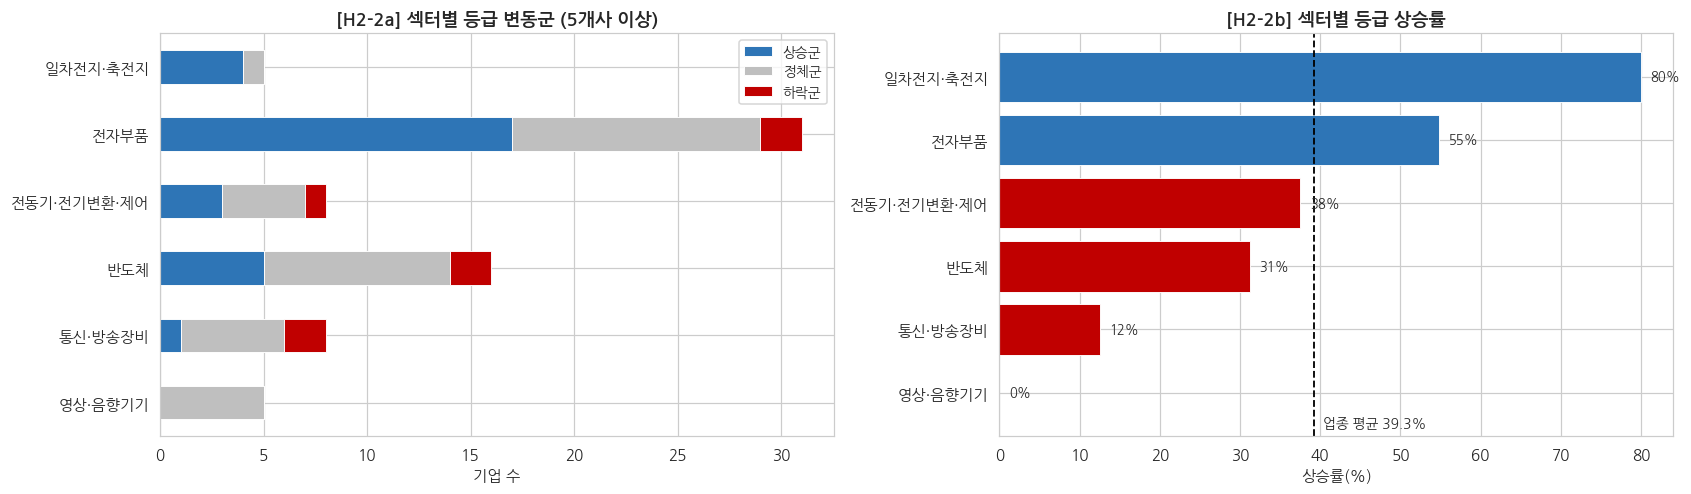

In [20]:
tb = ct2[ct2['합계'] >= 5].sort_values('상승률(%)')
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.6))
tb[['상승군', '정체군', '하락군']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[GRP_COLOR[g] for g in ['상승군', '정체군', '하락군']],
    edgecolor='white', linewidth=0.6)
axes[0].set_title('[H2-2a] 섹터별 등급 변동군 (5개사 이상)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('기업 수'); axes[0].set_ylabel(''); axes[0].legend(fontsize=9)

cols = ['#2E75B6' if v >= base else '#C00000' for v in tb['상승률(%)']]
axes[1].barh(tb.index, tb['상승률(%)'], color=cols, edgecolor='white', linewidth=0.6)
axes[1].axvline(base, color='black', ls='--', lw=1.2)
axes[1].text(base + 1, -0.55, f'업종 평균 {base:.1f}%', fontsize=9)
for y, v in enumerate(tb['상승률(%)']):
    axes[1].text(v + 1.2, y, f'{v:.0f}%', va='center', fontsize=8.5)
axes[1].set_title('[H2-2b] 섹터별 등급 상승률', fontsize=12, fontweight='bold')
axes[1].set_xlabel('상승률(%)')
plt.tight_layout(); plt.show()

### 2-3. 섹터 효과와 규모 효과 분리

In [21]:
big5 = ct2[ct2['합계'] >= 5].index.tolist()
d5 = p[p['섹터'].isin(big5)].dropna(subset=['log시총', 'ESG등급_점수']).copy()
d5['잔차'] = d5['ESG등급_점수'] - np.polyval(
    np.polyfit(d5['log시총'], d5['ESG등급_점수'], 1), d5['log시총'])

sz = (d5.groupby('섹터').agg(n=('ESG등급_점수', 'size'),
                            시총중앙_억=('시가총액_억', 'median'),
                            평균등급=('ESG등급_점수', 'mean'),
                            규모통제_잔차=('잔차', 'mean')).round(2))
sz['시총중앙_억'] = sz['시총중앙_억'].round(0).astype(int)
print('[2-3] 섹터별 규모와 등급')
print(sz.sort_values('규모통제_잔차', ascending=False).to_string())

gg = [d5[d5['섹터'] == s]['잔차'] for s in big5]
h, pv_r = stats.kruskal(*gg)
print(f'\n규모 통제 잔차에 대한 Kruskal-Wallis : H={h:.3f}  p={pv_r:.4f}')
print('  → p >= 0.05 이면 섹터 간 등급 차이는 사실상 규모 차이로 설명된다.')

[2-3] 섹터별 규모와 등급
                       n  시총중앙_억  평균등급  규모통제_잔차
섹터                                                          
전자부품              36         6161      2.78           0.22
일차전지·축전지        9        36761      3.67           0.13
영상·음향기기          6          787      1.50          -0.03
전동기·전기변환·제어  10        12419      2.80          -0.04
반도체                19         3841      2.21          -0.23
통신·방송장비          9         5894      2.33          -0.45

규모 통제 잔차에 대한 Kruskal-Wallis : H=4.938  p=0.4235
  → p >= 0.05 이면 섹터 간 등급 차이는 사실상 규모 차이로 설명된다.


---
# Part 3. 군집분석 — 상위군/하위군이 자연 분리되는가

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

FEAT = ['ESG등급_점수', '환경_점수', '사회_점수', '지배구조_점수',
        'log시총', '지속_2025', '지배_2025']
cl = p.dropna(subset=FEAT).copy()
Xs = StandardScaler().fit_transform(cl[FEAT])
print(f'군집 대상 : {len(cl)}개사, 변수 {len(FEAT)}개')

sil = {k: silhouette_score(Xs, KMeans(n_clusters=k, n_init=20, random_state=42)
                           .fit_predict(Xs)) for k in range(2, 7)}
print('[실루엣 점수]', {k: round(v, 3) for k, v in sil.items()})
BEST_K = max(sil, key=sil.get)
cl['군집'] = KMeans(n_clusters=BEST_K, n_init=20, random_state=42).fit_predict(Xs)
print(f'선택 : k={BEST_K}')

군집 대상 : 101개사, 변수 7개
[실루엣 점수] {2: 0.51, 3: 0.431, 4: 0.466, 5: 0.344, 6: 0.303}
선택 : k=2


[군집 프로파일]
      기업수  평균등급  환경  사회  지배구조  시총중앙_억  지속가능보고서율  지배구조보고서율
군집                                                                                         
1         46      4.09  4.30  5.24      3.26        17760              0.83              0.83
0         55      1.31  1.78  1.67      1.40         2468              0.11              0.09


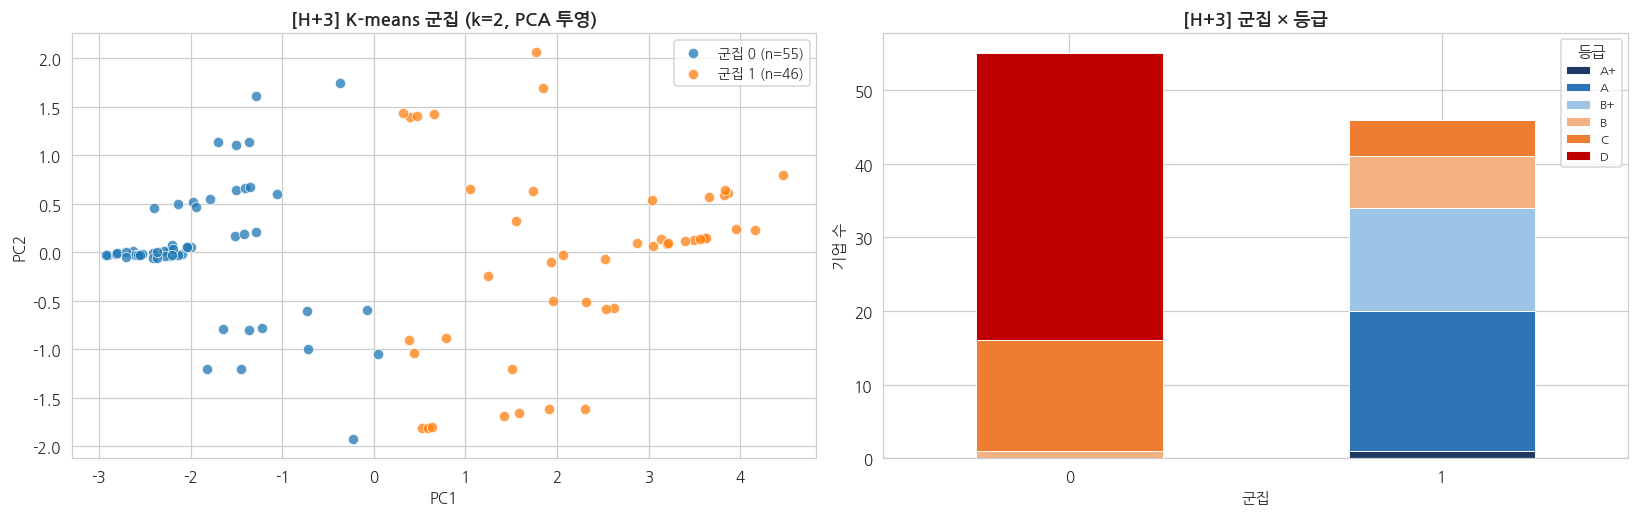

[군집 × 등급]
ESG등급  A+   A  B+  B   C   D
군집                          
0         0   0   0  1  15  39
1         1  19  14  7   5   0

[군집 × 변동군]
변동군  상승군  정체군  추적불가  하락군
군집                                    
0            7      29        12       7
1           26      14         5       1

[군집 × 섹터]
섹터  가정용기기  기타 전기장비  기타(코드 확인 필요)  반도체  영상·음향기기  일차전지·축전지  전구·조명  전동기·전기변환·제어  전자부품  절연선·케이블(전선)  컴퓨터·주변장치  통신·방송장비
군집                                                                                                                                                                                         
0              1              2                     0      12              5                1          1                     5        18                    2                2              6
1              1              0                     1       7              1                8          0                     5        18                    2                0              3


In [23]:
prof = (cl.groupby('군집').agg(
    기업수=('ESG등급_점수', 'size'), 평균등급=('ESG등급_점수', 'mean'),
    환경=('환경_점수', 'mean'), 사회=('사회_점수', 'mean'), 지배구조=('지배구조_점수', 'mean'),
    시총중앙_억=('시가총액_억', 'median'),
    지속가능보고서율=('지속_2025', 'mean'), 지배구조보고서율=('지배_2025', 'mean')).round(2))
prof['시총중앙_억'] = prof['시총중앙_억'].round(0).astype(int)
prof = prof.sort_values('평균등급', ascending=False)
print('[군집 프로파일]'); print(prof.to_string())

xy = PCA(n_components=2, random_state=42).fit_transform(Xs)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for c in sorted(cl['군집'].unique()):
    m = (cl['군집'] == c).values
    axes[0].scatter(xy[m, 0], xy[m, 1], s=46, alpha=0.75,
                    label=f'군집 {c} (n={int(m.sum())})', edgecolor='white', linewidth=0.6)
axes[0].set_title(f'[H+3] K-means 군집 (k={BEST_K}, PCA 투영)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(fontsize=9)

cg = pd.crosstab(cl['군집'], cl['ESG등급']).reindex(columns=GRADE_ORDER).fillna(0).astype(int)
cg.plot(kind='bar', stacked=True, ax=axes[1],
        color=[GRADE_COLOR[g] for g in GRADE_ORDER], edgecolor='white', linewidth=0.6)
axes[1].set_title('[H+3] 군집 × 등급', fontsize=12, fontweight='bold')
axes[1].set_xlabel('군집'); axes[1].set_ylabel('기업 수')
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(title='등급', fontsize=8)
plt.tight_layout(); plt.show()

print('[군집 × 등급]'); print(cg.to_string())
print(); print('[군집 × 변동군]'); print(pd.crosstab(cl['군집'], cl['변동군']).to_string())
print(); print('[군집 × 섹터]'); print(pd.crosstab(cl['군집'], cl['섹터']).to_string())

In [24]:
worst = prof.index[-1]
cand = (cl[cl['군집'] == worst][['기업명', '시장구분', '섹터', 'ESG등급',
                                '환경', '사회', '지배구조', '시가총액_억', '변동군',
                                '지속_2025', '지배_2025']]
        .sort_values('시가총액_억'))
cand['시가총액_억'] = cand['시가총액_억'].round(0).astype(int)
print(f'[컨설팅 1차 후보군] 최하위 군집 {worst} — {len(cand)}개사')
print(cand.to_string(index=False))
cand.to_csv('consulting_candidates.csv', index=False, encoding='utf-8-sig')
print('\n→ consulting_candidates.csv 저장')

[컨설팅 1차 후보군] 최하위 군집 0 — 55개사
            기업명 시장구분                 섹터 ESG등급 환경 사회 지배구조  시가총액_억   변동군  지속_2025  지배_2025
          에이엔피    KOSPI             전자부품       D    C    D        D          194   정체군        0.0        0.0
          주연테크    KOSPI      컴퓨터·주변장치       D    D    D        D          278   정체군        0.0        0.0
          금호전기    KOSPI            전구·조명       D    C    C        D          321   정체군        0.0        0.0
          경인전자    KOSPI             전자부품       D    D    D        D          322   정체군        0.0        0.0
          성문전자    KOSPI             전자부품       D    C    D        D          341   정체군        0.0        0.0
  엑시큐어하이트론    KOSPI        영상·음향기기       D    C    D        D          413   정체군        0.0        0.0
    주성코퍼레이션    KOSPI        통신·방송장비       D    C    C        D          418   정체군        0.0        0.0
        일진디스플    KOSPI               반도체       D    C    D        D          465   정체군        0.0        0.0
      삼화전자공업    KOSPI   

---
# 4. 가설 검증 결과 요약

In [25]:
res = []

# H1-1
res.append(['H1-1', 'ESG 등급 ~ 기업 규모 선형성',
            f'Pearson r={pr:.3f}, R²={rv**2:.3f}, n={len(x)} / 4분위 단조증가 {mono}',
            '부분 채택' if rv**2 >= 0.3 else '기각'])

# H1-2
r0_ = h12.loc[h12['보고서'] == '지속가능경영보고서', '단순 r'].values[0]
r1_ = h12.loc[h12['보고서'] == '지속가능경영보고서', '규모통제 편상관'].values[0]
res.append(['H1-2', '규모 통제 시 등급-보고서 상관 소멸',
            f'단순 r={r0_:.3f} → 편상관 {r1_:.3f}',
            '기각' if abs(r1_) >= 0.15 else '기각하지 못함'])

# H1-3
r3, p3 = stats.spearmanr(t.dropna(subset=['log시총', '전이'])['log시총'],
                         t.dropna(subset=['log시총', '전이'])['전이'])
res.append(['H1-3', '상승군 패턴은 규모와 무관',
            f'규모 vs 전이 rho={r3:+.3f} (p={p3:.3f}, n={int(t["전이"].notna().sum())})',
            '기각' if p3 < 0.05 else '기각하지 못함'])

# H1-4
dn_last = sr_rate.loc['하락군', '2025']; up_last = sr_rate.loc['상승군', '2025']
dn_first = sr_rate.loc['하락군', '2022']
res.append(['H1-4', '하락군은 이미 보고서를 발간',
            f'하락군 발행률 {dn_first}%(2022) → {dn_last}%(2025), n=8 / 상승군 {up_last}%(2025)',
            '기각' if dn_last < 50 else '기각하지 못함'])

# H2-1
tg = pol.reindex([t_ for t_ in TARGET if t_ in pol.index])
tg_txt = '; '.join(f"{k} std={v['표준편차']:.2f}/양극단={v['양극단비중']:.2f}(n={int(v['기업수'])})"
                   for k, v in tg.iterrows())
res.append(['H2-1', '반도체·2차전지·전선 양극화 없음',
            f'업종 전체 양극단={(hi_a+lo_a)/len(p):.2f} | {tg_txt}',
            '기각' if bool((tg['양극단비중'] >= 0.85).all()) else '기각하지 못함'])

# H2-2
rng = f"{ct2.loc[ct2['합계']>=5,'상승률(%)'].min():.0f}~{ct2.loc[ct2['합계']>=5,'상승률(%)'].max():.0f}%"
res.append(['H2-2', '상승군은 세부 섹터와 무관',
            f'섹터별 상승률 {rng}, chi2={chi2:.2f} p={pv_c:.3f} (기대빈도<5 {low:.0f}%)',
            '기각' if pv_c < 0.05 else '기각하지 못함'])

# H+1
res.append(['H+1', '보고서 신규 발행이 등급 상승에 선행',
            f"신규 발행군 {h_pre.loc[0,'평균 전이']:+.2f}(n={h_pre.loc[0,'n']}) vs "
            f"계속 미발행군 {h_pre.loc[1,'평균 전이']:+.2f}(n={h_pre.loc[1,'n']}), p={pv:.4f}",
            '채택' if pv < 0.05 else '기각'])

# H+2
res.append(['H+2', '상승·하락군은 특정 영역에서 갈림',
            '; '.join(f"{r['영역']} 상승군 {r['상승군 평균변화']:+.2f} / 하락군 {r['하락군 평균변화']:+.2f}"
                      for _, r in h2p.iterrows()),
            '본문 참조'])

# H+3
res.append(['H+3', '군집으로 상위/하위 자연 분리',
            f'k={BEST_K}, 실루엣 {sil[BEST_K]:.3f}, 최하위 군집 {len(cand)}개사',
            '채택' if sil[BEST_K] >= 0.25 else '약함'])

verdict = pd.DataFrame(res, columns=['가설', '내용', '핵심 수치', '판정'])
print(verdict.to_string(index=False))
verdict.to_csv('hypothesis_verdicts.csv', index=False, encoding='utf-8-sig')

# 분석 패널 저장
exp_cols = ['기업명', '시장구분', '섹터', 'KSIC3', '산업코드', '시가총액_억', '시총분위',
            'ESG등급', 'ESG등급_점수', '환경', '사회', '지배구조'] + \
           [f'등급_{y}' for y in YEARS] + ['전이', '변동군'] + \
           [f'지속_{y}' for y in YEARS] + [f'지배_{y}' for y in YEARS]
p.reset_index()[['기업코드'] + exp_cols].to_csv(
    'analysis_panel_전기전자.csv', index=False, encoding='utf-8-sig')
print('\n저장 : hypothesis_verdicts.csv / analysis_panel_전기전자.csv / consulting_candidates.csv')

가설                                내용                                                                                                                                           핵심 수치          판정
H1-1         ESG 등급 ~ 기업 규모 선형성                                                                                              Pearson r=0.703, R²=0.495, n=101 / 4분위 단조증가 True     부분 채택
H1-2  규모 통제 시 등급-보고서 상관 소멸                                                                                                                         단순 r=0.623 → 편상관 0.351          기각
H1-3           상승군 패턴은 규모와 무관                                                                                                             규모 vs 전이 rho=+0.251 (p=0.021, n=84)          기각
H1-4         하락군은 이미 보고서를 발간                                                                                   하락군 발행률 12.5%(2022) → 12.5%(2025), n=8 / 상승군 60.6%(2025)          기각
H2-1     반도체·2차전지·전선 양극화 없음 업종 전체 양극단=0.92 | 반도체 std=1.47/양극단=0.95(n=19); 일

---
## 5. 한계

1. **시가총액은 2025년 값만 존재한다.** 전이(2022→2025)를 과거 시점 규모로 통제하지 못했다.
   "올라서 커진 기업"과 "원래 컸던 기업"이 구분되지 않는다.
2. **H+1은 선후관계이지 인과가 아니다.** 출발점(2022년 미발행)을 맞춰 비교했으나,
   보고서를 낼 여력이 있는 기업이 다른 ESG 활동도 함께 시작했을 가능성을 배제하지 못한다.
   두 집단의 시가총액 차이 검정 결과를 함께 확인할 것.
3. **4개 산업 횡단 비교는 불가능하다.** 이번 데이터셋은 전기·전자만 담고 있다.
   H1-1~H1-4는 전기·전자 한정 결과다.
4. **섹터별 표본이 작다.** 5개사 미만 섹터(전구·조명 1, 컴퓨터·주변장치 2 등)는
   비율 수치를 단독 근거로 쓰지 않는다. 카이제곱 검정의 기대빈도 미달 경고도 함께 확인할 것.
5. **삼성SDI의 산업코드(C8202)는 오류로 보인다.** 값을 고치지 않고 별도 표기했다.
6. 모든 결과는 **상관·설명력·선후관계** 수준이며 인과로 해석하지 않는다.